# Lab 3 solution: Inverse Kinematics

Companion to `InverseKinematicsTemplate.ipynb` (`pdfs/Inverse_Kinematics.pdf`). **The code cells are the template's own cells with the blanks filled in**
(changes beyond the blanks are commented in the cell). After each code cell:
- **Concept**: what the task computes and why;
- **How it works**: the code line by line, every new piece of syntax with a tiny example;
- sometimes an **Example**: a short check, shown as code + its real output (text only, nothing extra to run).

**Real robot by default.** Tasks 1–17 are offline (laptop or Pi, no robot needed). Task 18 publishes a joint target to the real controller `mycobot_control` and **moves the arm**.
- ⚠ Run this notebook **cell by cell**, never "Run All". Cells that move the arm are marked **[MOVES]**: workspace clear,
  hand at the robot's power switch, first move small and slow.
- Cells that need the robot have **no saved output** here (they were not run on the laptop); all other outputs are real.

**Simulation (optional).** Blocks marked 🧪 show how to run the same cells **without** the robot, against
`solutions/sim_robot.py` (a simulated arm behind a virtual serial port). They come after the real-robot solution and
are never needed in the lab.

**Run from `solutions/`.** `import labpaths` (added to the setup cell) puts the repo root on `sys.path`, so
`helperFunctions.py` imports as in the template, and finds the course URDF `mycobot_280_gazebo.urdf` in the repo root.

**The idea of the lab.** Forward kinematics (FK) maps joint angles $q$ to a pose $T(q)$. Inverse kinematics (IK) asks
the reverse: which $q$ reaches a wanted pose? There may be several answers (elbow up/down), none (out of reach), or
answers beyond the joint limits. So IK is solved **numerically**: start from a guess (the *seed*) and reduce the pose
error step by step.

# Inverse Kinematics for the myCobot 280 Labs
## Lab 3: Numerical IK, Damped Least Squares, and Convergence Debugging

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Lab 1 (spatial transformations) and Lab 2 (manual FK vs URDF FK). Later labs can send live end-effector commands on `/mycobot/ee_pose` as `[x_mm, y_mm, z_mm, roll_deg, pitch_deg, yaw_deg]`, but all offline IK work in this notebook uses metres and radians.
        


In [1]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
from scipy.optimize import least_squares, minimize

import labpaths    # added: repo root on sys.path (helperFunctions.py) + URDF location
from helperFunctions import poseError, calculate_poseerror, transform_to_pipi, rpy_to_rot, rpy_to_transform

np.set_printoptions(precision=4, suppress=True)    # added: 4 decimals, no 1e-17 noise in printed arrays

**How it works**
- `from scipy.optimize import least_squares, minimize`: two general numerical optimisers (Tasks 9–11). You give them a
  function of $q$, they search for the $q$ that makes it small.
- `helperFunctions.py` holds the pose-error code shared with the robot controller:

| function | what it does |
|---|---|
| `rpy_to_rot(rpy)` | `[roll, pitch, yaw]` → $R = R_z(yaw)\,R_y(pitch)\,R_x(roll)$ (3×3) |
| `rpy_to_transform(xyz, rpy)` | 4×4 transform from a position and RPY angles |
| `poseError(target, achieved)` | 6-vector `[target_pos − achieved_pos, rot_to_vec(R_target R_achievedᵀ)]` |
| `calculate_poseerror(q, robot, bodyname, target, weights)` | runs FK at `q`, returns the (weighted) `poseError` |
| `transform_to_pipi(q)` | wraps angles into $[-\pi, \pi]$ |

- Why `R_target @ R_achievedᵀ`: it is the rotation that turns the achieved orientation into the target one,
  **expressed in the base frame**, the same frame as the Jacobian `jacob0` used later. Error and Jacobian fit together.

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed with this notebook. In the lab codebase the kinematic chain of interest runs from `g_base` to `joint6_flange`. Inspect the model and link names so that you know which chain you are solving.

Unlike the early textbook examples, this lab uses the URDF model directly: fixed `origin xyz/rpy` transforms are combined with the individual joint-axis rotations, rather than a DH-only chain.

**Pose-error formulation used in this lab:** The helper functions in `helperFunctions.py` compute the same 6D error as the myCobot 280 controller codebase. Position error is the 3D vector `target_pos - achieved_pos` in metres. Rotation error is extracted as an axis-angle vector from the relative rotation matrix `target_rot @ achieved_rot.T`, matching the `_rot_to_vec` method in `mycobot_control.py`. The full 6D error is `[pos_error(3), rot_error(3)]`.

In [2]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
if not os.path.exists(mycobot_urdf_path):        # added: the notebook runs in solutions/, the URDF is in the repo root
    mycobot_urdf_path = labpaths.urdf_path()
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

Using course URDF: /home/mano-ub22/TUD/cobots/mycobot_280_gazebo.urdf
ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)       

/tmp/ipykernel_65838/3780298154.py:5: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**Concept.** IK needs a kinematic model. The URDF describes every link as a fixed transform (`origin xyz rpy`)
followed by a rotation about the joint axis; the toolbox turns that into a chain it can differentiate.

**How it works**
- `rtb.Robot.URDF(path)` parses the XML and builds the robot. The path must be **absolute** (a relative path is looked
  up inside the toolbox's own data folder).
- `os.path.exists(p)` is `True` if the file exists; `labpaths.urdf_path()` returns the repo-root URDF.
- `mycobot.links` is a **list** of `Link` objects; `for link in mycobot.links:` visits them in order, `link.name` is the
  name from the URDF. IK is solved from `g_base` to `joint6_flange`.

### 2. Inspect the chain used for IK

Create the kinematic model that you will use for inverse kinematics. In this lab the end-effector comparison is made at `joint6_flange`. If your Robotics Toolbox version exposes explicit start and end selection, compare the chain from `g_base` to `joint6_flange`; otherwise use the model ending at `joint6_flange`.
        


In [3]:
bodyname = 'joint6_flange'
mycobot_ets = mycobot.ets(end=bodyname)
print(mycobot_ets)
print(f'Number of joints: {mycobot.n}')

SE3() ⊕ SE3() ⊕ SE3(0, 0, 0.1396) ⊕ Rz(q0) ⊕ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1) ⊕ SE3(-0.1104, 0, 0) ⊕ Rz(q2) ⊕ SE3(-0.096, 0, 0.06462; 0°, -0°, -90°) ⊕ Rz(q3) ⊕ SE3(0, -0.07318, -0.001; -90°, -90°, 180°) ⊕ Rz(q4) ⊕ SE3(0, 0.0456, 0; -90°, -0°, 0°) ⊕ Rz(q5)
Number of joints: 6


**Concept.** The IK solver works on an **elementary transform sequence** (ETS): the chain written as a product of
constant transforms and joint rotations.

**How it works**
- `mycobot.ets(end='joint6_flange')` returns that sequence from the base to the flange: `SE3(...)` are fixed offsets,
  `Rz(q0)` … `Rz(q5)` the six joint rotations, `⊕` means "followed by".
- `mycobot.n` = number of joints. In `f'...{x}'` (an **f-string**) the expression in braces is inserted as text.
- 6 joints, 6 pose components (3 position + 3 orientation): a reachable pose has finitely many exact solutions.

## The Hard Problem

Inverse kinematics is harder than forward kinematics because the same target pose can admit multiple joint solutions, no exact solution, or solutions that depend strongly on the initial guess. In this lab you will compare three practical numerical approaches for the myCobot 280:

- toolbox-based IK
- generic nonlinear least-squares IK
- custom damped least-squares Jacobian IK

### 3. Generate a Robotics Toolbox IK solver

Use a full six-element task-space mask so that both position and orientation are included in the solve.

In [4]:
mask = [1, 1, 1, 1, 1, 1]
ik_mycobot = rtb.IK_LM(mask=mask, seed=0)    # seed=0 added: repeatable random restarts, same numbers every run

**Concept.** `IK_LM` is the toolbox's **Levenberg–Marquardt** solver: Gauss–Newton steps ("solve $J\,\Delta q = e$")
with a damping term that keeps the steps sane near singularities. If a search stalls or leaves the joint limits it
**restarts** from a random configuration.

**How it works**
- `mask` picks which pose-error components count, in the order `[x, y, z, rx, ry, rz]`: 1 = enforce, 0 = ignore.
  All ones = full pose.
- `seed=0` fixes the random generator of the restarts. Without it two runs can end in two different valid solutions.

**Example: position only (orientation free)**

```python
ik_position_only = rtb.IK_LM(mask=[1, 1, 1, 0, 0, 0], seed=0)
qd, ok, its, srch, res, why = ik_position_only.solve(mycobot_ets, SE3(0.18, 0.04, 0.18), np.zeros(6))
print(ok, its, 'reached position (m):', mycobot.fkine(qd, end=bodyname).t)
```

Output:
```text
True 4 reached position (m): [0.1788 0.0395 0.1802]
```

Ignoring the orientation makes the problem easier: a suction cup that only has to reach a point needs no more. `SE3(x, y, z)` is a pure translation; `.t` is the translation part of a pose.

### 4. Define a realistic myCobot 280 target pose

Build a target pose from a translation and an RPY orientation, consistent with Labs 1 and 2. Start from a reachable pose such as `x=0.18 m`, `y=0.04 m`, `z=0.18 m` and moderate angles. If a solve fails, reduce the orientation demand or move the target closer to the base.

Keep everything in metres and radians inside this notebook. Only the live controller topic `/mycobot/ee_pose` uses millimetres and degrees.
        


In [5]:
target_xyz_m = np.array([0.18, 0.04, 0.18])
target_rpy_rad = np.array([0.0, np.deg2rad(35.0), np.deg2rad(20.0)])

# Build the target pose using the same RPY convention as the codebase:
# rpy_to_transform takes [x,y,z] and [roll,pitch,yaw], builds R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
target_pose = SE3(rpy_to_transform(target_xyz_m, target_rpy_rad))

print(target_pose)

   0.7698   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04      
  -0.5736    0         0.8192    0.18      
   0         0         0         1         



**Concept.** A target **pose** = position + orientation. Here 18 cm forward, 4 cm left, 18 cm up, tilted 35° about
y (pitch) and turned 20° about z (yaw).

**How it works**
- `np.deg2rad(35.0)` converts degrees to radians; inside the notebook everything stays in metres and radians.
- `rpy_to_transform(xyz, rpy)` builds the 4×4 matrix (rotation block top-left, position in the last column).
- `SE3(array_4x4)` wraps it as a pose object that `solve` and `fkine` understand; printing shows the matrix.

### 5. Solve IK from a zero seed

Use the zero configuration as the first seed. Record whether the solve succeeds, the returned residual, and the final joint vector.
        


In [6]:
q0_zero = np.zeros(mycobot.n)
q_toolbox, success, iterations, searches, residual, reason = ik_mycobot.solve(
    mycobot_ets,
    target_pose,
    q0_zero,
)

print('success:', success)
print('iterations:', iterations)
print('searches:', searches)
print('residual:', residual)
print('reason:', reason)
print('q_toolbox:', transform_to_pipi(q_toolbox))

success: True
iterations: 242
searches: 9
residual: 3.330803545899099e-08
reason: Success
q_toolbox: [ 2.9261  0.1335  2.2291 -0.2575 -0.3119 -1.0922]


**Concept.** The solver starts at $q = 0$ and iterates until the pose error is below its tolerance.

**How it works**
- `solve(ets, target, q0)` returns **six values**; `a, b, c, d, e, f = ...` unpacks them (**tuple unpacking**):
  `q` (solution), `success`, `iterations` (total steps), `searches` (number of starts, 1 = no restart needed),
  `residual` (final error size), `reason` (text).
- `transform_to_pipi` wraps angles into $[-\pi, \pi]$, so 6.5 rad reads as 0.22 rad.
- `searches > 1` means the zero seed failed at least once and a random restart found the answer. The answer is **one**
  of possibly several valid joint sets (Task 7).

### 6. Evaluate the achieved pose and task-space error

Compare the target pose with the achieved pose from forward kinematics. Use the helper functions from earlier labs to evaluate the pose error in task space.
        


In [7]:
achieved_pose_toolbox = mycobot.fkine(q_toolbox)
poseerror_toolbox = calculate_poseerror(q_toolbox, mycobot, bodyname, target_pose)
poseerror_toolbox_direct = poseError(target_pose, achieved_pose_toolbox)

print('myCobot 280')
print('Target pose:\n', target_pose)
print('Achieved pose:\n', achieved_pose_toolbox)
print('Helper-function ||e(q)||:', np.linalg.norm(poseerror_toolbox))
print('Direct poseError ||e||:', np.linalg.norm(poseerror_toolbox_direct))

myCobot 280
Target pose:
    0.7698   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04      
  -0.5736    0         0.8192    0.18      
   0         0         0         1         

Achieved pose:
    0.7697   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04006   
  -0.5736    1.735e-05  0.8191    0.1798    
   0         0         0         1         

Helper-function ||e(q)||: 0.00025810089290426104
Direct poseError ||e||: 0.00025810089290426104


**Concept.** IK gives a $q$; **FK checks it**. The pose error between target and achieved pose says how good the
solution is.

**How it works**
- `mycobot.fkine(q)`: the pose the flange really reaches at `q`.
- `calculate_poseerror(q, ...)` does the FK itself; `poseError(target, achieved)` compares two poses you already have.
  Same 6-vector, so the two norms agree.
- `np.linalg.norm(e)` = $\sqrt{e_1^2 + \dots + e_6^2}$. It mixes metres and radians, which is why the custom solver
  later checks position and rotation **separately**.

**Example: read the error vector in units you can feel**

```python
e = poseerror_toolbox
print('position error (mm):', e[:3] * 1000)
print('rotation error (deg):', np.degrees(e[3:]))    # axis-angle vector: its length is the angle in rad
```

Output:
```text
position error (mm): [ 0.046  -0.0609  0.244 ]
rotation error (deg): [-0.0003 -0.002   0.0004]
```

`e[:3]` = first three entries (slicing), `e[3:]` = from index 3 to the end.

## Multiple Seed Strategies

### 7. Compare several initial guesses

A numerical IK solver can converge to different local solutions, or fail, depending on its starting configuration. Test the same target from several seeds and compare convergence, residual, and final joint vectors.

In [8]:
# Arbitrary seed candidates for comparison (codebase geometric seeds are explored in the next task)
seed_candidates = {
    'zero': np.zeros(mycobot.n),
    'seed_a': np.array([0.0, 0.4, -0.6, 0.0, 0.4, 0.0]),
    'seed_b': np.array([0.3, -0.2, 0.5, -0.4, 0.2, 0.1]),
    'seed_c': np.array([-0.4, 0.1, -0.3, 0.6, -0.2, 0.0]),
}

toolbox_seed_results = {}

for seed_name, q0 in seed_candidates.items():
    q_sol, success, iterations, searches, residual, reason = ik_mycobot.solve(
        mycobot_ets,
        target_pose,
        q0,
    )

    toolbox_seed_results[seed_name] = {
        'success': success,
        'iterations': iterations,
        'searches': searches,
        'residual': residual,
        'reason': reason,
        'q': transform_to_pipi(q_sol),
    }

toolbox_seed_results

{'zero': {'success': True,
  'iterations': 41,
  'searches': 2,
  'residual': 1.0006643333465086e-07,
  'reason': 'Success',
  'q': array([ 2.9269,  0.1328,  2.23  , -0.2574, -0.3115, -1.0931])},
 'seed_a': {'success': True,
  'iterations': 76,
  'searches': 4,
  'residual': 1.1339588543774984e-08,
  'reason': 'Success',
  'q': array([ 2.9256,  0.1301,  2.2284, -0.2537, -0.3122, -1.0918])},
 'seed_b': {'success': True,
  'iterations': 38,
  'searches': 2,
  'residual': 1.1737659564490287e-08,
  'reason': 'Success',
  'q': array([ 2.9256,  2.0772, -2.2288,  2.2564, -0.3123, -1.0918])},
 'seed_c': {'success': True,
  'iterations': 53,
  'searches': 3,
  'residual': 9.631329732332285e-10,
  'reason': 'Success',
  'q': array([ 2.9258,  2.0776, -2.2277,  2.255 , -0.3121, -1.092 ])}}

**Concept.** Numerical IK is **local**: the seed decides which solution (or which failure) you get.

**How it works**
- `{'name': value, ...}` is a **dictionary**; `.items()` yields `(key, value)` pairs, and `for seed_name, q0 in ...:`
  unpacks each pair.
- The results are stored as a **dictionary of dictionaries**: `toolbox_seed_results['seed_a']['q']`.
- A bare name on the last line of a cell (`toolbox_seed_results`) makes Jupyter display it.

**Example: the same results as a table**

```python
def print_seed_table(results):
    print(f"{'seed':22s} {'ok':5s} {'iters':>5s} {'searches':>8s} {'residual':>10s}   q (rad)")
    for name, r in results.items():
        print(f"{name:22s} {str(r['success']):5s} {r['iterations']:5d} {r.get('searches', 0):8d} "
              f"{r['residual']:10.1e}   {r['q']}")

print_seed_table(toolbox_seed_results)
```

Output:
```text
seed                   ok    iters searches   residual   q (rad)
zero                   True     41        2    1.0e-07   [ 2.9269  0.1328  2.23   -0.2574 -0.3115 -1.0931]
seed_a                 True     76        4    1.1e-08   [ 2.9256  0.1301  2.2284 -0.2537 -0.3122 -1.0918]
seed_b                 True     38        2    1.2e-08   [ 2.9256  2.0772 -2.2288  2.2564 -0.3123 -1.0918]
seed_c                 True     53        3    9.6e-10   [ 2.9258  2.0776 -2.2277  2.255  -0.3121 -1.092 ]
```

Format specs in f-strings: `{s:22s}` text padded to 22 characters, `{n:5d}` integer in 5 characters,
`{x:10.1e}` scientific notation with 1 decimal. `r.get('searches', 0)` returns 0 if the key is missing.
**What to look for:** rows with the same $q_1, q_5, q_6$ but different $q_2, q_3, q_4$ are the **elbow-up / elbow-down**
pair: two exact solutions of the same pose. `searches > 1` means a random restart, not the seed, decided the branch.

### 8. Reproduce the codebase geometric seed strategy

The myCobot 280 controller uses three seed strategies when solving IK in `_solve_ik()`:

1. **Current joint angles** — the best seed when the robot is already near the target.
2. **Geometric elbow-down** — J1 points at the target XY, remaining joints set to a stretched-down pose: `[atan2(ty, tx), -0.5236, -1.5708, -0.7854, 0.0, 0.0]`.
3. **Geometric elbow-up** — Same J1, but with an elbow-up configuration: `[atan2(ty, tx), -0.7854, -1.0472, -1.0472, 0.0, 0.0]`.

The geometric seeds point J1 toward the target in the XY plane, which gives the Jacobian solver a good starting direction for far-reaching targets. Reproduce these seeds for your target pose and compare them with the arbitrary seeds from the previous task.

In [9]:
# Codebase geometric seed strategy (from _solve_ik in mycobot_control.py)
target_pos = target_pose.A[:3, 3]
j1_guess = np.arctan2(target_pos[1], target_pos[0])

seed_current = np.zeros(mycobot.n)  # placeholder for "current joint angles"
seed_elbow_down = np.array([j1_guess, -0.5236, -1.5708, -0.7854, 0.0, 0.0])
seed_elbow_up = np.array([j1_guess, -0.7854, -1.0472, -1.0472, 0.0, 0.0])

codebase_seeds = {
    'current_angles': seed_current,
    'geometric_elbow_down': seed_elbow_down,
    'geometric_elbow_up': seed_elbow_up,
}

codebase_seed_results = {}

for seed_name, q0 in codebase_seeds.items():
    q_sol, success, iterations, searches, residual, reason = ik_mycobot.solve(
        mycobot_ets,
        target_pose,
        q0,
    )
    codebase_seed_results[seed_name] = {
        'success': success,
        'iterations': iterations,
        'residual': residual,
        'q': transform_to_pipi(q_sol),
    }

codebase_seed_results

{'current_angles': {'success': True,
  'iterations': 51,
  'residual': 1.8319926898061604e-08,
  'q': array([ 2.9256,  0.1296,  2.2287, -0.2535, -0.3122, -1.0917])},
 'geometric_elbow_down': {'success': True,
  'iterations': 46,
  'residual': 2.993461605057561e-10,
  'q': array([ 2.9257,  0.1316,  2.2277, -0.2544, -0.3121, -1.0919])},
 'geometric_elbow_up': {'success': True,
  'iterations': 272,
  'residual': 5.763506793294908e-10,
  'q': array([ 2.9258,  2.0779, -2.2277,  2.2547, -0.3121, -1.092 ])}}

**Concept.** The controller does not guess randomly: joint 1 can be computed from the geometry (point the arm's
vertical plane at the target), the other joints get a typical elbow-down or elbow-up shape. A seed in the right
*basin* converges fast and to the intended solution.

**How it works**
- `target_pose.A` is the 4×4 NumPy array; `[:3, 3]` = rows 0–2 of column 3 = the position.
- `np.arctan2(y, x)` = angle of the point $(x, y)$ seen from the origin, correct in all four quadrants (unlike
  `arctan(y/x)`). Example: `np.arctan2(1, -1)` = 2.356 rad = 135°, `np.arctan(1/-1)` = −45°.
- The fixed numbers are radians: −0.5236 = −30°, −0.7854 = −45°, −1.0472 = −60°, −1.5708 = −90°.
- `seed_current` is a placeholder here; on the robot the controller uses the **measured** angles, the best seed for a
  target near the current pose (Task 18 does exactly that).

## Numerical vs Analytical IK

Analytical IK uses closed-form formulas when a robot structure allows them. Numerical IK iteratively reduces pose error and is usually easier to adapt to a URDF-based model.

For the myCobot 280 lab series, the practical focus is numerical IK. The controller and debugging workflow are built around the URDF model, Jacobians, seeds, residuals, and convergence behaviour rather than a separate closed-form solver.

## Generic Nonlinear Least-Squares IK

### 9. Build the optimization objective

Reuse `calculate_poseerror(q, robot, bodyname, targetpose)` as the residual function for `least_squares`. If you also want to try `minimize`, wrap the residual in a scalar sum-of-squares objective.

In [10]:
def calculate_scalar_poseerror(q, robot, bodyname, targetpose, errorweights=None):
    if errorweights is None:
        errorweights = np.ones(6)
    e = calculate_poseerror(q, robot, bodyname, targetpose, errorweights)
    return 0.5 * np.sum(e**2)

**Concept.** IK as optimisation: find $q$ that minimises $\tfrac12\lVert e(q)\rVert^2$, zero exactly at an exact
solution. `least_squares` takes the **vector** $e(q)$ (it squares and sums itself); `minimize` needs one **number**, hence
this wrapper.

**How it works**
- `errorweights=None` is a **default argument**: if the caller passes nothing, all six components weigh 1.
- `e**2` squares element-wise, `np.sum` adds up: $\sum e_i^2$.

### 10. Solve the IK problem with `least_squares` and optionally `minimize`

Use Levenberg-Marquardt as the main path. BFGS is optional and only makes sense with the scalar objective. Compare these results against the toolbox solver.

In [11]:
q0_lm = np.zeros(mycobot.n)

q_lm = least_squares(
    calculate_poseerror,
    q0_lm,
    method='lm',
    ftol=1e-6,
    xtol=1e-6,
    gtol=1e-6,
    args=(mycobot, bodyname, target_pose),
)

q_bfgs = minimize(
    calculate_scalar_poseerror,
    q0_lm,
    args=(mycobot, bodyname, target_pose),
    method='BFGS',
    tol=1e-6,
)

print('LM q:', transform_to_pipi(q_lm.x))
print('LM ||e||:', np.linalg.norm(q_lm.fun))
print('BFGS q:', transform_to_pipi(q_bfgs.x))
print('BFGS cost:', q_bfgs.fun)

LM q: [ 2.9258  0.1319  2.2276 -0.2545 -0.3121 -1.0919]
LM ||e||: 1.3854430726445248e-13
BFGS q: [ 0.6167 -1.7484 -0.0001  2.7252 -0.1523  1.3498]
BFGS cost: 3.026339495665473e-06


**Concept.** Two generic solvers on the same problem: Levenberg–Marquardt for least squares, BFGS (quasi-Newton) for a
scalar cost. **Neither knows the joint limits.**

**How it works**
- `least_squares(fun, x0, args=(a, b, c))` calls `fun(x, a, b, c)`: the unknown first, then the `args` tuple. That is why
  `calculate_poseerror(q, robot, bodyname, targetpose)` takes `q` first.
- `ftol`, `xtol`, `gtol`: stop when the cost, the step or the gradient change less than this.
- Result objects: `.x` = best $q$, `.fun` = residual vector (LM) or final cost (BFGS), `.success`, `.nfev` = number of
  function calls.

**Example: are the generic solutions physically possible?**

```python
def within_limits(q, robot=mycobot):
    q = np.asarray(q, dtype=float)
    return bool(np.all((q >= robot.qlim[0]) & (q <= robot.qlim[1])))

print('LM raw q (rad)        :', q_lm.x)
print('LM wrapped within     :', within_limits(transform_to_pipi(q_lm.x)))
print('BFGS wrapped within   :', within_limits(transform_to_pipi(q_bfgs.x)))
print('toolbox within        :', within_limits(q_toolbox))
```

Output:
```text
LM raw q (rad)        : [ 59.4744  18.9814   2.2276 -37.9537 -75.7103 -13.6583]
LM wrapped within     : True
BFGS wrapped within   : False
toolbox within        : True
```

`robot.qlim` is 2×6 (row 0 lower, row 1 upper limits); `&` is element-wise "and", `np.all` demands every joint.
`least_squares` treats angles as plain numbers: its raw answer can be many full turns away from the same pose. **Always
wrap with `transform_to_pipi` and check the limits** before a solution goes near the robot.

### 11. Compare pose error for the optimization-based solvers

Evaluate the achieved poses and compare the residuals from toolbox IK, generic least squares, and optional BFGS.

In [12]:
achieved_pose_lm = mycobot.fkine(q_lm.x)
poseerror_lm = calculate_poseerror(q_lm.x, mycobot, bodyname, target_pose)

achieved_pose_bfgs = mycobot.fkine(q_bfgs.x)
poseerror_bfgs = calculate_poseerror(q_bfgs.x, mycobot, bodyname, target_pose)

print('Toolbox IK ||e||:', np.linalg.norm(poseerror_toolbox))
print('LM least_squares ||e||:', np.linalg.norm(poseerror_lm))
print('BFGS ||e||:', np.linalg.norm(poseerror_bfgs))

Toolbox IK ||e||: 0.00025810089290426104
LM least_squares ||e||: 1.3854430726445248e-13
BFGS ||e||: 0.0024602192974064216


**Concept.** Same FK check as Task 6 for every solver: "converged" only means *the solver's own stopping test* fired.

**How it works / reading the numbers**
- Each solver stops on its own criterion (toolbox: its `tol`; LM: `ftol/xtol/gtol`). BFGS minimises the *squared*
  error, whose gradient gets very flat near the minimum, so it tends to stop earlier with a larger residual.
- Lesson: always **verify with FK**, and compare residuals in units you understand (mm, degrees).

## Damped Least-Squares Jacobian IK

### 12. Complete a damped least-squares update

Implement a Jacobian-based IK loop for the myCobot 280. Use the model Jacobian and the damped least-squares update

\[
\Delta q = J^T\left(JJ^T + \lambda^2 I\right)^{-1} e
\]

or an equivalent numerically stable formulation with `np.linalg.solve`.

Store debugging data at every iteration:

- iteration index
- residual norm
- step norm
- current joint vector

This mirrors the workflow used in the separate `ik_debug.py` debugging script from the codebase.

The codebase applies a step-size scaling factor (default `ik_step = 0.5`) to improve stability:

$q_{k+1} = q_k + \alpha \, \Delta q$

where $\alpha$ is the `step` parameter. A smaller step is more conservative but converges more slowly.

**Separate tolerances:** The codebase uses `ik_pos_tol_m = 0.002` (2 mm) for position and `ik_rot_tol_rad = 0.02` (~1.1°) for rotation, checked independently. The solver converges only when *both* are satisfied.

In [13]:
def damped_least_squares_ik(robot, bodyname, targetpose, q0, damping=1e-2, step=0.5, pos_tol=0.002, rot_tol=0.02, max_iters=100, clamp_joints=True):
    q = np.array(q0, dtype=float).copy()
    history = []

    qlim = getattr(robot, 'qlim', None)
    if qlim is not None:
        qlim = np.asarray(qlim)

    for k in range(max_iters):
        e = calculate_poseerror(q, robot, bodyname, targetpose)
        err_norm = np.linalg.norm(e)
        pos_err_norm = np.linalg.norm(e[:3])
        rot_err_norm = np.linalg.norm(e[3:])

        history.append(
            {
                'iteration': k,
                'error_norm': err_norm,
                'pos_error_norm': pos_err_norm,
                'rot_error_norm': rot_err_norm,
                'step_norm': 0.0,
                'q': q.copy(),
            }
        )

        if pos_err_norm <= pos_tol and rot_err_norm <= rot_tol:
            break

        J = robot.jacob0(q, end=bodyname)                    # 6x6 geometric Jacobian in the base frame
        lambda2_I = damping**2 * np.eye(6)                   # lambda^2 * I
        dq = J.T @ np.linalg.solve(J @ J.T + lambda2_I, e)   # J^T (J J^T + lambda^2 I)^-1 e

        q = q + step * dq

        if clamp_joints and qlim is not None:
            q = np.clip(q, qlim[0, :], qlim[1, :])

        history[-1]['step_norm'] = np.linalg.norm(dq)

    return q, history

**Concept.** Linearised FK: $J\,\Delta q \approx e$. Solving $\Delta q = J^{-1}e$ explodes near a singularity (some
$\sigma_i$ of $J$ → 0). **Damped least squares** minimises $\lVert J\Delta q - e\rVert^2 + \lambda^2\lVert\Delta q\rVert^2$
("reduce the error, but penalise big joint steps"); its solution is $\Delta q = J^T(JJ^T + \lambda^2 I)^{-1}e$. This is
the algorithm inside `mycobot_control` (`_solve_ik`).

**How it works (the three filled lines and the loop around them)**
- `robot.jacob0(q, end=bodyname)`: 6×6 geometric Jacobian in the **base** frame (rows 0–2 linear, 3–5 angular velocity),
  the same frame and order as the error `e`.
- `damping**2 * np.eye(6)`: $\lambda^2 I$ (`np.eye(6)` = 6×6 identity).
- `np.linalg.solve(A, b)` solves $Ax = b$ without forming $A^{-1}$ (faster, numerically safer than `inv(A) @ b`);
  `J.T @ x` completes the formula. `@` is matrix multiplication, `.T` the transpose.
- `q = q + step * dq`: take only a fraction ($\alpha$ = `step` = 0.5): the linearisation is valid only near $q$.
- `np.array(q0, dtype=float).copy()`: a **copy**, otherwise the caller's seed array would change (arrays are passed by
  reference). Same reason for `'q': q.copy()` in the history.
- Convergence test: position ≤ 2 mm **and** rotation ≤ 0.02 rad, separately (metres and radians must not be added).
- `history[-1]` = the last entry (index −1); `break` leaves the loop early.

**Example: why the damping matters near a singularity**

```python
J_demo = np.array([[1.0, 0.0],
                   [0.0, 1e-4]])          # second direction almost lost (nearly singular)
e_demo = np.array([0.01, 0.01])
lam = 0.05
print('plain inverse step:', np.linalg.solve(J_demo, e_demo))
print('damped step       :', J_demo.T @ np.linalg.solve(J_demo @ J_demo.T + lam**2 * np.eye(2), e_demo))
```

Output:
```text
plain inverse step: [  0.01 100.  ]
damped step       : [0.01   0.0004]
```

In the strong direction ($\sigma = 1$) DLS changes almost nothing; in the weak one ($\sigma = 10^{-4}$) it refuses to
ask for a 100 rad motion. In SVD terms each direction gets the gain $\sigma/(\sigma^2 + \lambda^2)$ instead of $1/\sigma$:
smaller λ = more accurate but violent near singularities, larger λ = smooth but slow.

### 13. Add joint-limit clamping

Clamp the joint vector after each Jacobian update. If the model exposes `mycobot.qlim`, use it. If not, create a temporary `q_min` / `q_max` structure from your lab notes and write down where those limits came from. Do not invent exact limits without checking the model or the myCobot documentation.

In [14]:
if getattr(mycobot, 'qlim', None) is not None:
    qlim = np.asarray(mycobot.qlim)
else:
    # myCobot 280 data-sheet limits (deg), the same numbers as gameplan.md; used only if the URDF had no limits
    qlim = np.radians(np.array([[-168, -135, -150, -145, -165, -180],
                                [ 168,  135,  150,  145,  165,  180]]))  # 2 x n array: first row q_min, second row q_max

print('qlim shape:', np.shape(qlim))

def clamp_to_limits(q, qlim):
    return np.clip(q, qlim[0, :], qlim[1, :])

qlim shape: (2, 6)


**Concept.** A solution outside the joint range is useless for the robot. Clamping after every step keeps the
iterate inside (crude: if only some joints are cut, the step direction is distorted and the solver can stall at a limit,
Task 14).

**How it works**
- `getattr(obj, 'qlim', None)` reads an attribute, or returns `None` if it does not exist.
- The `else` branch documents its source (data sheet, `gameplan.md`), as the task asks. The URDF has limits, so it is
  not used here.
- `np.clip(q, lo, hi)`: element-wise, values below `lo` become `lo`, above `hi` become `hi`.
  Example: `np.clip([4.0, -3.0], [-2.9, -2.6], [2.9, 2.6])` → `[2.9, -2.6]`.

## Convergence Debugging

### 14. Run the custom Jacobian solver with several seeds and damping values

Use the same target pose with different seeds and damping values. Track whether the error drops smoothly, stalls, oscillates, or becomes unstable. This is the same style of offline convergence analysis used in `ik_debug.py`.

In [15]:
debug_runs = []

all_seeds = {**seed_candidates, **codebase_seeds}
for seed_name, q0 in all_seeds.items():
    for damping in [1e-3, 1e-2, 1e-1]:
        q_dls, history = damped_least_squares_ik(
            mycobot,
            bodyname,
            target_pose,
            q0,
            damping=damping,
            step=0.5,
            pos_tol=0.002,
            rot_tol=0.02,
            max_iters=100,
            clamp_joints=True,
        )
        debug_runs.append(
            {
                'seed': seed_name,
                'damping': damping,
                'q': q_dls,
                'history': history,
                'final_error': history[-1]['error_norm'] if history else np.nan,
            }
        )

len(debug_runs)    # template: debug_runs (prints all 21 histories, ~2000 entries); the table below is readable

21

**Concept.** The same target from 7 seeds × 3 damping values: does the error drop smoothly, stall, or oscillate?

**How it works**
- `{**a, **b}` merges two dictionaries (`**` unpacks a dictionary into the new one).
- Two nested loops → 21 runs; each stores the final $q$ and the full history.
- `x if condition else y` is a one-line `if/else` **expression**; `np.nan` = "not a number".

**Example: result table**

```python
def run_table(runs, pos_tol=0.002, rot_tol=0.02):
    print(f"{'seed':22s} {'lambda':>7s} {'iters':>5s} {'pos err [mm]':>13s} {'rot err [rad]':>14s}  converged  joints at a limit")
    for run in runs:
        h = run['history']
        pos, rot = h[-1]['pos_error_norm'], h[-1]['rot_error_norm']
        at_limit = np.isclose(run['q'], qlim[0], atol=1e-6) | np.isclose(run['q'], qlim[1], atol=1e-6)
        print(f"{run['seed']:22s} {run['damping']:7.0e} {len(h):5d} {pos*1000:13.2f} {rot:14.4f}  "
              f"{str(pos <= pos_tol and rot <= rot_tol):9s}  {[j + 1 for j in range(6) if at_limit[j]]}")

run_table(debug_runs)
```

Output:
```text
seed                    lambda iters  pos err [mm]  rot err [rad]  converged  joints at a limit
zero                     1e-03   100         65.34         0.7262  False      [4]
zero                     1e-02   100         11.89         0.1669  False      [4]
zero                     1e-01   100          4.31         0.0150  False      [4]
seed_a                   1e-03   100         18.63         0.4086  False      [5]
seed_a                   1e-02   100          6.64         1.3881  False      [5, 6]
seed_a                   1e-01   100          4.29         0.0154  False      [4]
seed_b                   1e-03   100          5.15         0.1129  False      [5]
seed_b                   1e-02   100         11.89         0.1669  False      [4]
seed_b                   1e-01   100          4.52         0.0120  False      [4]
seed_c                   1e-03   100         93.95         1.4019  False      [1, 4, 5]
seed_c                   1e-02   100         58.93         0.5195  False      [1, 5]
seed_c                   1e-01   100          4.29         0.0153  False      [4]
current_angles           1e-03   100         65.34         0.7262  False      [4]
current_angles           1e-02   100         11.89         0.1669  False      [4]
current_angles           1e-01   100          4.31         0.0150  False      [4]
geometric_elbow_down     1e-03   100        140.72         3.0376  False      [4]
geometric_elbow_down     1e-02   100         63.17         0.5515  False      [4]
geometric_elbow_down     1e-01   100         58.22         0.2754  False      [4]
geometric_elbow_up       1e-03   100         87.97         0.9752  False      [4]
geometric_elbow_up       1e-02   100         72.21         0.7430  False      [4]
geometric_elbow_up       1e-01   100         58.22         0.2754  False      [4]
```

`np.isclose(a, b, atol=...)` compares element-wise with a tolerance; `|` is element-wise "or".
`[j + 1 for j in range(6) if at_limit[j]]` is a **list comprehension with a filter**: joint numbers that sit at a limit.
**Reading it (this run, course URDF):** none of the 21 runs reaches the tolerance within 100 iterations, and almost
every one ends with a joint, mostly joint 4, pressed against its limit. That is a **stall caused by the limit**, not a bug:
from these seeds the solver walks towards a configuration with joint 1 ≈ 0.6 rad whose exact solution needs joint 4
slightly beyond its range (the unconstrained BFGS of Task 10 found it). The two valid solutions of Task 7 have joint 1 ≈
2.93 rad, close to its 168° limit and far from every seed here (−0.4…0.3 rad), so DLS never enters their basin.
λ = 1e-3 thrashes (errors up to 140 mm), λ = 1e-1 is the calmest (≈ 4 mm). Lesson: when DLS stalls with a joint at a
limit, change the seed or the target orientation, not the iteration count.

### 15. Plot the convergence history (position and rotation separately)

Plot at least the error norm per iteration. Also inspect the joint-step norm so that you can tell whether convergence is stalling because the solver is taking tiny steps or because it is bouncing around the target.

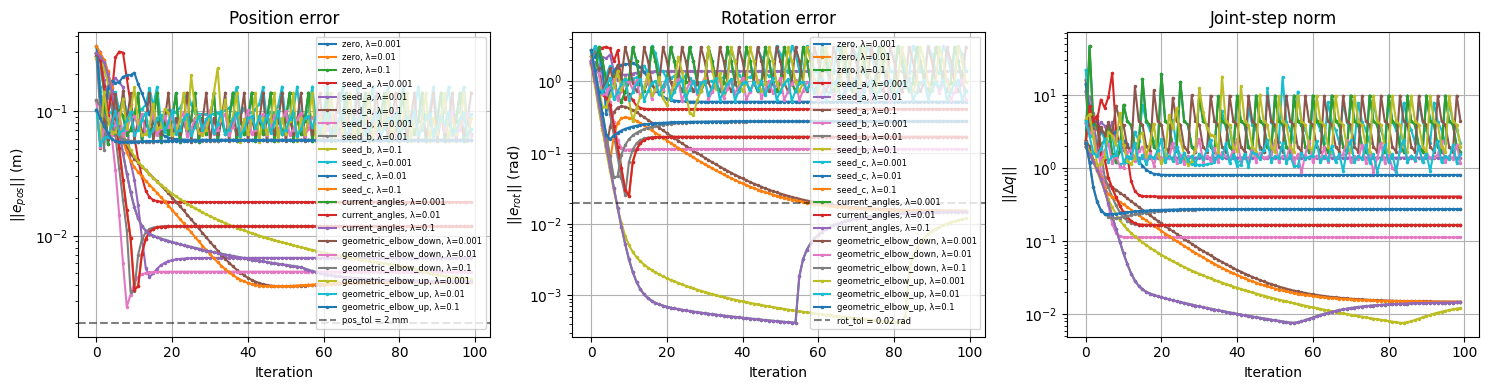

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for run in debug_runs:
    iterations = [entry['iteration'] for entry in run['history']]
    pos_norms = [entry['pos_error_norm'] for entry in run['history']]
    rot_norms = [entry['rot_error_norm'] for entry in run['history']]
    step_norms = [entry['step_norm'] for entry in run['history']]
    label = f"{run['seed']}, λ={run['damping']}"

    axes[0].semilogy(iterations, pos_norms, marker='.', markersize=3, label=label)
    axes[1].semilogy(iterations, rot_norms, marker='.', markersize=3, label=label)
    axes[2].semilogy(iterations, step_norms, marker='.', markersize=3, label=label)

axes[0].set_title('Position error')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$||e_{pos}||$ (m)')
axes[0].axhline(0.002, color='k', linestyle='--', alpha=0.5, label='pos_tol = 2 mm')
axes[0].grid(True)
axes[0].legend(fontsize=6)

axes[1].set_title('Rotation error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$||e_{rot}||$ (rad)')
axes[1].axhline(0.02, color='k', linestyle='--', alpha=0.5, label='rot_tol = 0.02 rad')
axes[1].grid(True)
axes[1].legend(fontsize=6)

axes[2].set_title('Joint-step norm')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'$||\Delta q||$')
axes[2].grid(True)

plt.tight_layout()

**Concept.** On a logarithmic error axis, an error that shrinks by a constant factor per step is a **straight line**.
The step norm tells *why* a curve flattens.

| shape | meaning |
|---|---|
| straight line downwards | healthy convergence |
| plateau, step norm also tiny | **stall**: local minimum, joint limit, near-singular pose |
| plateau, step norm stays large | **oscillation**: overshooting; more damping or a smaller `step` |
| error grows | unstable: `step` too big or λ too small near a singularity |

**How it works**
- `plt.subplots(1, 3, figsize=(15, 4))`: one figure, three plots side by side; `axes[0..2]` are the plot areas.
- `[entry['iteration'] for entry in run['history']]`: a **list comprehension** pulls one field out of every entry.
- `semilogy` = log y-axis; `axhline(y)` draws the tolerance line a curve must get below; `tight_layout()` stops labels
  from overlapping. `r'$...$'` is a raw string with LaTeX for the axis label.

### 16. Reproduce the ik_debug.py convergence workflow

The codebase includes `scripts/ik_debug.py`, a standalone script that tests IK convergence on specific target poses and plots iteration-by-iteration error. In this task, replicate that workflow inside the notebook: solve two different target poses from the same seed and overlay their convergence curves. This lets you see how target reachability affects convergence behaviour.

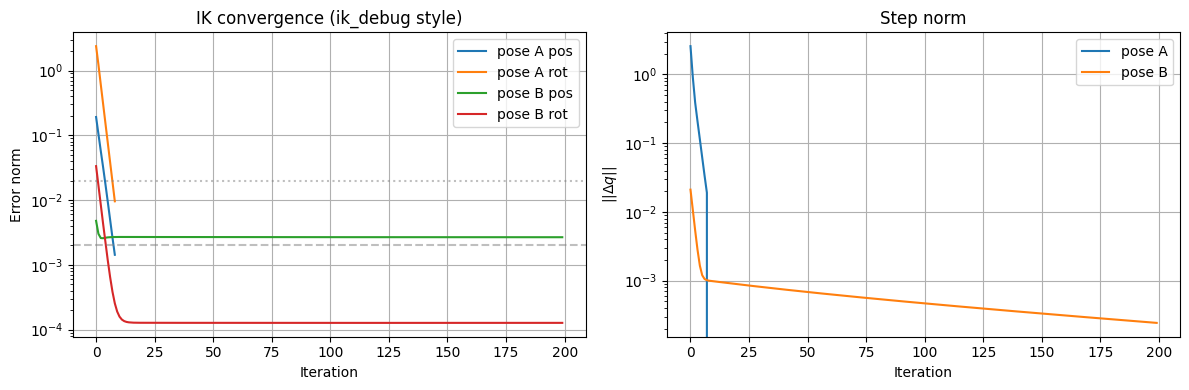

In [17]:
# Two target poses (similar to defaults in ik_debug.py)
pose_a_xyzrpy = [0.0880, -0.0645, 0.2315, 2.337, -0.007, -1.5888]  # m, rad
pose_b_xyzrpy = [0.0502, -0.0639, 0.4194, -1.601, -0.009, -1.5817]  # m, rad

def xyzrpy_to_se3(xyzrpy):
    """Build SE3 from [x, y, z, roll, pitch, yaw] using the codebase RPY convention."""
    return SE3(rpy_to_transform(xyzrpy[:3], xyzrpy[3:6]))

target_a = xyzrpy_to_se3(pose_a_xyzrpy)
target_b = xyzrpy_to_se3(pose_b_xyzrpy)

q0_debug = np.zeros(mycobot.n)

_, hist_a = damped_least_squares_ik(mycobot, bodyname, target_a, q0_debug,
                                     damping=0.05, step=0.5, max_iters=200)
_, hist_b = damped_least_squares_ik(mycobot, bodyname, target_b, q0_debug,
                                     damping=0.05, step=0.5, max_iters=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy([h['iteration'] for h in hist_a], [h['pos_error_norm'] for h in hist_a], label='pose A pos')
axes[0].semilogy([h['iteration'] for h in hist_a], [h['rot_error_norm'] for h in hist_a], label='pose A rot')
axes[0].semilogy([h['iteration'] for h in hist_b], [h['pos_error_norm'] for h in hist_b], label='pose B pos')
axes[0].semilogy([h['iteration'] for h in hist_b], [h['rot_error_norm'] for h in hist_b], label='pose B rot')
axes[0].set_title('IK convergence (ik_debug style)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error norm')
axes[0].axhline(0.002, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(0.02, color='gray', linestyle=':', alpha=0.5)
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy([h['iteration'] for h in hist_a], [h['step_norm'] for h in hist_a], label='pose A')
axes[1].semilogy([h['iteration'] for h in hist_b], [h['step_norm'] for h in hist_b], label='pose B')
axes[1].set_title('Step norm')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$||\Delta q||$')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

**Concept.** Same seed, same settings, two targets: how **reachability** shapes convergence. Pose B is 42 cm high,
about the height of the fully stretched arm.

**How it works**
- `xyzrpy[:3]` / `xyzrpy[3:6]`: slicing a list into position and angles.
- `_, hist_a = f(...)`: the function returns `(q, history)`; `_` is the usual name for a value you do not need.
- The triple-quoted string right under `def` is a **docstring**: the function's built-in description
  (`help(xyzrpy_to_se3)` prints it).

**Example: unreachable, or only hard for this solver?**

```python
for name, tgt, hist in (('A', target_a, hist_a), ('B', target_b, hist_b)):
    q_t, ok, its, srch, res, why = ik_mycobot.solve(mycobot_ets, tgt, q0_debug)
    e_t = calculate_poseerror(q_t, mycobot, bodyname, tgt)
    print(f"pose {name}: DLS {len(hist)} iterations, {hist[-1]['pos_error_norm']*1000:.2f} mm | toolbox success={ok}, "
          f"searches={srch}, {np.linalg.norm(e_t[:3])*1000:.2f} mm")
```

Output:
```text
pose A: DLS 9 iterations, 1.43 mm | toolbox success=True, searches=1, 0.08 mm
pose B: DLS 200 iterations, 2.67 mm | toolbox success=False, searches=100, 3.41 mm
```

If the toolbox solver with all its random restarts also fails, the target is at or beyond the edge of the workspace
with that orientation: no seed helps. Tip for the robot: check reachability (FK, distance from the base) before
sending a target.

## Compare Solver Behaviours

### 17. Summarize the three IK approaches

Compare the toolbox IK solution, the generic `least_squares` solution, and your custom damped least-squares Jacobian solution in terms of:

- convergence speed
- final residual
- sensitivity to initialization
- practicality for the myCobot 280 stack

Keep the discussion short and evidence-based. Use the residuals and debug plots rather than guesses.

In [18]:
best_debug_run = min(debug_runs, key=lambda run: run['final_error'])

solver_summary = {
    'toolbox': {
        'q': transform_to_pipi(q_toolbox),
        'residual_norm': np.linalg.norm(poseerror_toolbox),
    },
    'least_squares_lm': {
        'q': transform_to_pipi(q_lm.x),
        'residual_norm': np.linalg.norm(poseerror_lm),
    },
    'dls_custom': {
        'q': transform_to_pipi(best_debug_run['q']),
        'residual_norm': best_debug_run['final_error'],
        'seed': best_debug_run['seed'],
        'damping': best_debug_run['damping'],
    },
}

solver_summary

{'toolbox': {'q': array([ 2.9261,  0.1335,  2.2291, -0.2575, -0.3119, -1.0922]),
  'residual_norm': 0.00025810089290426104},
 'least_squares_lm': {'q': array([ 2.9258,  0.1319,  2.2276, -0.2545, -0.3121, -1.0919]),
  'residual_norm': 1.3854430726445248e-13},
 'dls_custom': {'q': array([ 0.6234, -1.903 ,  0.3378,  2.5307, -0.1561,  1.3443]),
  'residual_norm': 0.012799511530056441,
  'seed': 'seed_b',
  'damping': 0.1}}

**Concept.** One answer per approach, to compare on evidence.

**How it works**
- `min(runs, key=lambda run: run['final_error'])`: the element with the smallest final error. `lambda run: ...` is a
  tiny unnamed function that tells `min` what to compare.

**Example: timing and joint limits for the comparison**

```python
import time

def timed(fn, repeat=5):
    t0 = time.perf_counter()
    for _ in range(repeat):
        fn()
    return (time.perf_counter() - t0) / repeat

times = {'toolbox': timed(lambda: ik_mycobot.solve(mycobot_ets, target_pose, q0_zero)),
         'least_squares_lm': timed(lambda: least_squares(calculate_poseerror, q0_zero, method='lm',
                                                         args=(mycobot, bodyname, target_pose))),
         'dls_custom': timed(lambda: damped_least_squares_ik(mycobot, bodyname, target_pose, q0_zero, damping=0.1))}
for name, s in solver_summary.items():
    print(f"{name:18s} ||e|| {s['residual_norm']:9.2e}   {times[name]*1000:6.1f} ms   within limits: {within_limits(s['q'])}")
```

Output:
```text
toolbox            ||e||  2.58e-04      7.8 ms   within limits: True
least_squares_lm   ||e||  1.39e-13      6.4 ms   within limits: True
dls_custom         ||e||  1.28e-02     11.0 ms   within limits: True
```

| | toolbox `IK_LM` | `least_squares` (LM) | custom DLS |
|---|---|---|---|
| speed | ms | ms | slowest (Python loop, fixed step) |
| residual | stops at its `tol` | tiny (after wrapping) | often stops at a joint limit above the 2 mm tolerance |
| seed sensitivity | low: restarts itself, but the branch varies | medium: no restarts, local minima | high |
| joint limits | respected | **ignored**, check afterwards | respected by clamping |
| on the robot | offline planning | if you check the limits | what the controller runs: transparent and tunable |

The custom DLS is the least efficient and the most explainable: you choose tolerance, damping and step, and it is the
code inside `mycobot_control`. In the interview you should be able to explain each of its lines.

## Bridge to the Live Controller

### 18. Send an IK solution to the real robot

Pick the best IK solution from the solver comparison above and publish it to `/mycobot/joint_command` as a `Float64MultiArray`. The topic expects joint angles in **radians**. The controller converts to degrees internally before sending to the hardware via the serial interface.

This closes the loop: you solved IK offline in the notebook, and now you command the real robot to move to that configuration.

Ensure the `mycobot_control` launch is running in a separate terminal before publishing.

**[MOVES] Real robot.** Before the cell below: `mycobot_control` running on the Pi (`ros2 launch mycobot_control
mycobot_control.launch.py`), the notebook's ROS environment matching it (same `ROS_DOMAIN_ID`), workspace clear, hand
at the power switch.

**Why the template line `q_best = solver_summary['toolbox']['q']` is not sent as it is.** IK returns *a* solution, not
the one *closest to where the arm is*. The Task 4 target needs joint 1 near its limit, a half-turn from any normal pose,
and `/mycobot/joint_command` is one `send_angles` at speed 50 with no step limit. So the cell follows the template's
"or replace with your preferred solution": it reads the measured pose, asks IK for a target **2 cm above the current
flange pose**, seeded with the current angles, and refuses any joint step above 15°.

In [ ]:
import rclpy
from rclpy.node import Node
from std_msgs.msg import Float64MultiArray
from sensor_msgs.msg import JointState                    # added: read the measured pose
from rclpy.wait_for_message import wait_for_message       # added

if not rclpy.ok():
    rclpy.init(args=None)

class IKPublisherNode(Node):
    def __init__(self):
        super().__init__('ik_lab_publisher')
        self.pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)

ik_node = IKPublisherNode()

# Use the best solution from the solver comparison  -> replaced: a target near the MEASURED pose (see above)
ok, js = wait_for_message(JointState, ik_node, '/mycobot/joint_states', time_to_wait=3.0)
assert ok, 'no /mycobot/joint_states: is mycobot_control running (same ROS_DOMAIN_ID)?'
q_now = np.array(js.position)
target_near = SE3.Tz(0.02) * mycobot.fkine(q_now)                       # 2 cm up (base z), same orientation
q_best, ik_ok, *_ = ik_mycobot.solve(mycobot_ets, target_near, q_now)   # seed = current pose -> nearest solution
step_deg = np.degrees(transform_to_pipi(q_best - q_now))
print('joint steps (deg):', np.round(step_deg, 2))
assert ik_ok and np.all(np.abs(step_deg) <= 15), 'IK failed or a joint would move more than 15 deg: not sent'

msg = Float64MultiArray()
msg.data = q_best.tolist()
ik_node.pub.publish(msg)
print(f'Published q = {q_best} to /mycobot/joint_command')

rclpy.spin_once(ik_node, timeout_sec=0.5)

# Optional cleanup:
# ik_node.destroy_node()
# rclpy.shutdown()

**Concept.** Close the loop: IK solved in the notebook, executed by the controller. `/mycobot/joint_command` takes six
joint angles in **radians**; `mycobot_control` converts them to degrees and sends one `send_angles` over the serial
port.

**How it works**
- The node class is the Lab 2 pattern: a `Node` subclass whose constructor creates a publisher
  (`create_publisher(type, topic, queue_size)`).
- `wait_for_message(Type, node, topic, time_to_wait=3.0)` waits for **one** message and returns `(ok, msg)`.
  `js.position` is the list of six angles in radians.
- `SE3.Tz(0.02) * T`: multiplying from the **left** moves the pose 2 cm along the **base** z axis (from the right it would
  move along the flange's own z axis).
- `q_best, ik_ok, *_ = ...`: **star-unpacking**: the first two values get names, `*_` collects the rest.
- Seeding with `q_now` makes the solver converge to the solution nearest the current pose.
- `transform_to_pipi(q_best - q_now)` wraps the difference, so +179° → −179° counts as 2°, not 358°.
- `assert condition, 'message'` stops the cell with that message if the condition is false: nothing is published.
- `msg.data = q_best.tolist()`: ROS messages need plain Python lists, not NumPy arrays.

⚠ **What `/mycobot/joint_states` really is** (read in `mycobot_control.py`, `_state_timer`; seen in the simulation,
not yet checked on the robot): the controller publishes its **estimate** of the angles at 5 Hz and reads the robot only
right after a command. After a `/mycobot/joint_command` that read happens immediately, before the arm has moved, so the
published pose stays at the *old* angles until the next command. Two consequences: (1) the "measured" pose you read
can lag one move behind; (2) a **velocity** command sent after a position command first drives the joints back towards
that stale estimate. Refresh the estimate after a position move by publishing the same target again once the arm has
stopped (no motion, but a new read). (3) Ending a velocity command with zeros makes the controller send **STOP** to the
robot, and the position path (`_pos_cb`) never sends **RESUME**; if the robot ignores motion after STOP (as the Lab 7
template says, and the simulation does), every later `/mycobot/joint_command` is ignored until a new velocity command
makes the controller resume. Wake-up: publish one small velocity message (e.g. 0.02 rad/s on one joint), then the position
command. **[check] on the robot.**

> ### 🧪 Simulation (optional, only without the robot)
> The code cell above is the real-robot version. To run it **without** the robot:
> 1. Terminal 1 (laptop): `python3 solutions/sim_robot.py` → it prints the virtual port, e.g. `/dev/pts/5`.
> 2. Terminal 2: start the **real** controller node on that port, isolated from the lab network:
>    ```bash
>    source /opt/ros/jazzy/setup.bash && source ros2_ws/install/setup.bash
>    export ROS_DOMAIN_ID=99 ROS_AUTOMATIC_DISCOVERY_RANGE=LOCALHOST
>    ros2 run mycobot_control mycobot_control --ros-args -p port:=/dev/pts/5 -p read_timeout_s:=0.75
>    ```
> 3. Notebook: restart the kernel, run the cells from the top up to (not including) the ROS cell, run the cell below,
>    then the ROS cell(s) above. Terminal 1 prints every command the simulated arm receives.
>
> ⚠ The isolation (`ROS_DOMAIN_ID=99`, localhost only) is what keeps a simulation from commanding the real arm: with the
> lab's domain id, the same `/mycobot/...` messages would also reach the real controller on the Pi. It must be set
> **before** `rclpy.init()`, hence the kernel restart.

In [ ]:
# SIMULATION ONLY: run before rclpy.init() (after a kernel restart), never in the lab with the real robot
import os
os.environ['ROS_DOMAIN_ID'] = '99'                           # not the lab's domain id
os.environ['ROS_AUTOMATIC_DISCOVERY_RANGE'] = 'LOCALHOST'    # talk only to nodes on this computer

---
## Summary
- IK solves $T(q) = T_{target}$ numerically; the result depends on the **seed**, may not be unique or may not exist, and
  can violate joint limits unless the solver enforces them.
- Error vector = `[Δposition, axis-angle of R_target R_actualᵀ]`, checked with **separate** tolerances (2 mm, 0.02 rad).
- DLS: $\Delta q = J^T(JJ^T + \lambda^2 I)^{-1}e$, $q \leftarrow q + \alpha\,\Delta q$, then clamp to the limits.
- Convergence plots: straight line down = good, plateau + tiny step = stall, plateau + big step = oscillation.
- On the robot: solve **from the measured pose**, check every joint step before publishing.